## Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


## Loading Model

In [2]:
model = tf.keras.models.load_model("Trained_model.keras")

In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

## Visualsing Single Image of Test Set

In [4]:
import cv2
# image_path = "test/test/AppleCedarRust1.JPG"
# image_path = "test/test/CornCommonRust2.JPG"
# image_path = "test/test/TomatoHealthy2.JPG"
image_path = "test/test/TomatoYellowCurlVirus3.JPG"


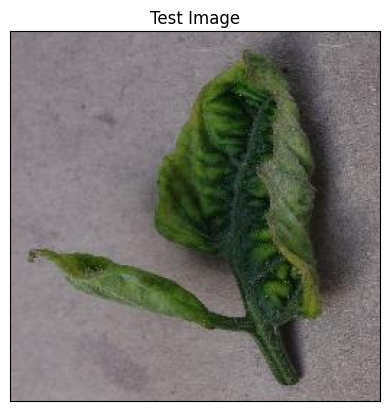

In [5]:
# reading image
img = cv2.imread(image_path)
# here we need to convert this image into its original color format
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Display Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])  # to remove the numbering on the x axis
plt.yticks([])
plt.show()

## Testing Model 


In [6]:
image = tf.keras.preprocessing.image.load_img(image_path, target_size = (128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
print(input_arr)

[[[133. 127. 131.]
  [129. 123. 127.]
  [135. 129. 133.]
  ...
  [126. 120. 122.]
  [119. 113. 115.]
  [106. 100. 102.]]

 [[129. 123. 127.]
  [127. 121. 125.]
  [131. 125. 129.]
  ...
  [118. 112. 114.]
  [109. 103. 105.]
  [119. 113. 115.]]

 [[132. 126. 130.]
  [140. 134. 138.]
  [138. 132. 136.]
  ...
  [134. 128. 130.]
  [123. 117. 119.]
  [110. 104. 106.]]

 ...

 [[143. 137. 139.]
  [143. 137. 139.]
  [146. 140. 142.]
  ...
  [129. 119. 120.]
  [138. 128. 129.]
  [122. 112. 113.]]

 [[148. 142. 144.]
  [149. 143. 145.]
  [145. 139. 141.]
  ...
  [141. 131. 132.]
  [142. 132. 133.]
  [134. 124. 125.]]

 [[152. 146. 148.]
  [155. 149. 151.]
  [151. 145. 147.]
  ...
  [132. 122. 123.]
  [108.  98.  99.]
  [133. 123. 124.]]]


In [7]:
input_arr = np.array([input_arr])  # doing this to convert it into batches as we have trained our model
print(input_arr.shape)

(1, 128, 128, 3)


In [8]:
prediction = model.predict(input_arr)

1/1 [==============================] - 7s 7s/step


In [9]:
prediction

array([[8.0415729e-04, 7.6187243e-05, 1.4497259e-03, 3.0598738e-03,
        1.5904639e-04, 2.7636722e-07, 5.6608019e-06, 8.1784421e-08,
        1.9501877e-05, 7.7729776e-05, 1.6103333e-05, 7.2953268e-04,
        9.5433037e-04, 6.5073401e-08, 1.8635623e-05, 1.5455086e-07,
        2.3240464e-04, 3.2582984e-04, 2.7440974e-04, 1.1744996e-04,
        2.0847899e-04, 2.2322229e-04, 1.3295353e-04, 8.4651285e-04,
        5.7244968e-05, 1.5376962e-03, 1.1067718e-02, 8.7065091e-05,
        3.9032616e-03, 7.5776976e-01, 1.5103516e-02, 3.7166197e-02,
        1.3456386e-01, 1.8681547e-07, 8.5517028e-03, 1.0869927e-07,
        2.0404434e-02, 5.4938086e-05]], dtype=float32)

In [10]:
prediction.shape

(1, 38)

In [11]:
result_index = np.argmax(prediction)
result_index

29

In [12]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [13]:
# Displaying Result of disease prediction
model_prediction = class_name[result_index]

In [14]:
model_prediction

'Tomato___Early_blight'

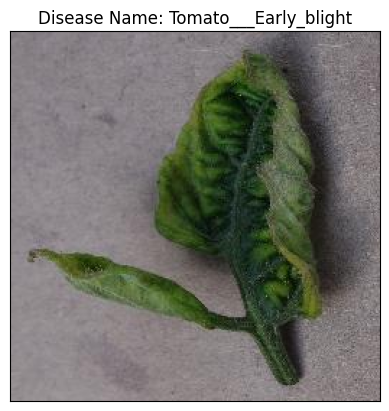

In [15]:
#Display Image
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])  # to remove the numbering on the x axis
plt.yticks([])
plt.show()